# House Prices: Advanced Regression Techniques

## 1. Environment Setup & Data Loading

In this initial step, we import the required libraries, configure the environment settings, and load our datasets.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_style("whitegrid")
pd.pandas.set_option('display.max_columns', None)

train = pd.read_csv("Data/train.csv")
test = pd.read_csv("Data/test.csv")

train_id = train["Id"]
test_id = test["Id"]

train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

## 2. Exploratory Data Analysis (EDA)
Here, we visualize the distribution of missing values across the dataset to inform our engineering strategies.

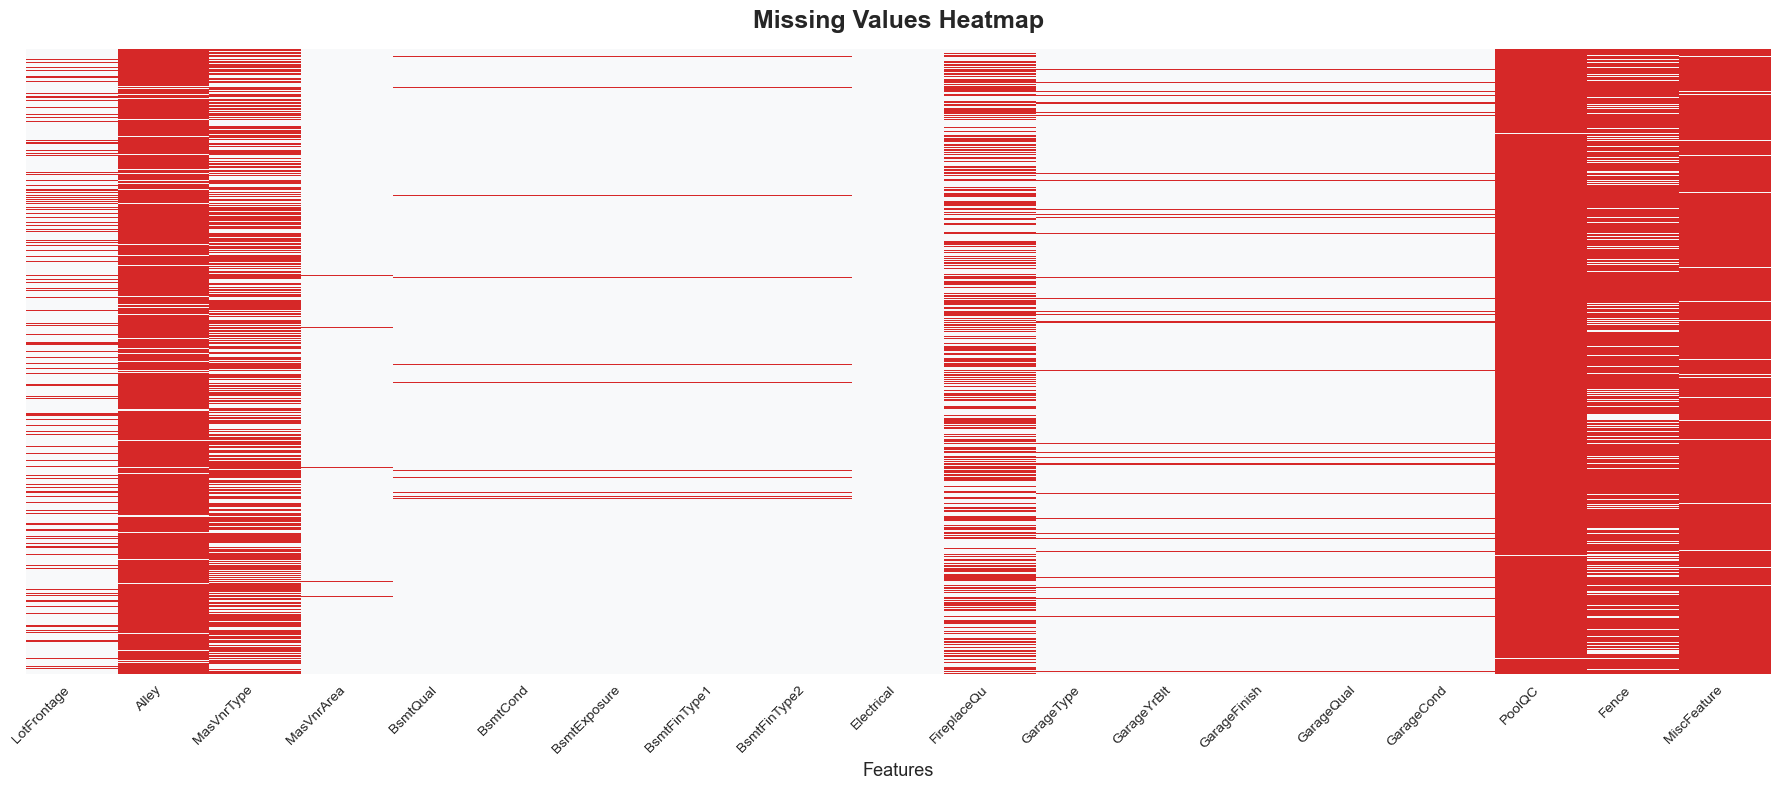

In [ ]:
missing_cols = train.columns[train.isnull().sum() > 0]

plt.figure(figsize=(18, 8))
sns.heatmap(
    train[missing_cols].isnull(),
    cmap=["#F8F9FA", "#D62828"],
    cbar=False,
    yticklabels=False,
    linewidths=0,
)
plt.title("Missing Values Heatmap", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Features", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

## 3. Feature Engineering
We clean the data by dropping highly sparse features, engineering domain-specific interaction variables, handling missing values strategically, and transforming skewed data distributions.

Drop Highly Sparse Columns & Feature Creation

In [ ]:
cols_to_drop = train.columns[train.isnull().mean() > 0.60]
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True, errors="ignore")

for df in [train, test]:
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
    
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    
    df["OverallQual_GrLivArea"] = df["OverallQual"] * df["GrLivArea"]
    df["OverallQual_TotalSF"] = df["OverallQual"] * df["TotalSF"]

Handling Missing Values

In [ ]:
train["Electrical"] = train["Electrical"].fillna(train["Electrical"].mode()[0])

cols = train.columns[(train.isnull().mean() > 0) & (train.isnull().mean() < 0.10)]
for col in cols:
    if train[col].dtype == 'object':
        train[col] = train[col].fillna(train[col].mode()[0])
    else:
        train[col] = train[col].fillna(train[col].median())

train["LotFrontage"] = train.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
train["MasVnrType"] = train["MasVnrType"].fillna("None")
train["FireplaceQu"] = train["FireplaceQu"].fillna("None")

test["Electrical"] = test["Electrical"].fillna(train["Electrical"].mode()[0])

cols = test.columns[(test.isnull().mean() > 0) & (test.isnull().mean() < 0.10)]
for col in cols:
    if test[col].dtype == 'object':
        test[col] = test[col].fillna(train[col].mode()[0])
    else:
        test[col] = test[col].fillna(train[col].median())

if "LotFrontage" in test.columns:
    test["LotFrontage"] = test.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))
if "MasVnrType" in test.columns:
    test["MasVnrType"] = test["MasVnrType"].fillna("None")
if "FireplaceQu" in test.columns:
    test["FireplaceQu"] = test["FireplaceQu"].fillna("None")

Skewness Correction & Outlier Removal

In [ ]:
train["SalePrice"] = np.log1p(train["SalePrice"])

from scipy.stats import skew
numeric = train.select_dtypes(include=np.number)
skewness = numeric.apply(lambda x: skew(x.dropna()))
skewed_features = skewness[abs(skewness) > 0.75].index

for feature in skewed_features:
    train[feature] = np.log1p(train[feature])
    if feature in test.columns:
        test[feature] = np.log1p(test[feature])

num_cols = train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = train.select_dtypes(include=["object"]).columns
train = train.drop(train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 13)].index)

print(len(num_cols),len(cat_cols))

Numerical Features: 49 | Categorical Features: 39


One-Hot Encoding & Feature Realignment

In [ ]:
train = pd.get_dummies(train, drop_first=True)
test = pd.get_dummies(test, drop_first=True)

X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

X, test = X.align(test, join="left", axis=1, fill_value=0)

## Model Selection & Cross-Validation
We setup our base model pool, benchmark each candidate algorithm utilizing a 10-fold cross-validation scheme, and record the metrics.

In [ ]:
!pip install catboost -q
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "Elastic Net": ElasticNet(alpha=0.001, l1_ratio=0.5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "XGBoost": xgb.XGBRegressor(random_state=42),
    "LightGBM": lgb.LGBMRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(verbose=0, random_state=42)
}

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    rmse = np.sqrt(
        -cross_val_score(
            model,
            X,
            y,
            cv=kf,
            scoring="neg_mean_squared_error"
        )
    )
    print(f"{name:<20} RMSE = {rmse.mean():.5f}")

Linear Regression    RMSE = 0.15414
Ridge                RMSE = 0.12984


c:\Users\aj647\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.528e+00, tolerance: 2.042e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aj647\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.673e+00, tolerance: 2.067e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aj647\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.342e+00, toleranc

Lasso                RMSE = 0.12747


c:\Users\aj647\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.828e+00, tolerance: 2.042e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aj647\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.656e+00, tolerance: 2.067e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\aj647\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.077e+00, toleranc

Elastic Net          RMSE = 0.12666
Decision Tree        RMSE = 0.20643
Random Forest        RMSE = 0.13929
Extra Trees          RMSE = 0.13500
Gradient Boosting    RMSE = 0.12702
KNN                  RMSE = 0.25089
SVR                  RMSE = 0.27576
XGBoost              RMSE = 0.13679
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4605
[LightGBM] [Info] Number of data points in the train set: 1314, number of used features: 169
[LightGBM] [Info] Start training from score 12.025324
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004798 seconds.
You can set `force_col_wise=true` to remo

In [ ]:
cat = CatBoostRegressor(verbose=0, random_state=42)
xgb_model = xgb.XGBRegressor(random_state=42)
lgb_model = lgb.LGBMRegressor(random_state=42)

cat.fit(X, y)
xgb_model.fit(X, y)
lgb_model.fit(X, y)

cat_pred = cat.predict(test)
xgb_pred = xgb_model.predict(test)
lgb_pred = lgb_model.predict(test)

final_pred = (
    0.50 * cat_pred +
    0.30 * lgb_pred +
    0.20 * xgb_pred
)

final_pred = np.expm1(final_pred)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002381 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4698
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 171
[LightGBM] [Info] Start training from score 12.024057


In [ ]:
submission = pd.DataFrame({
    "Id": test_id,
    "SalePrice": final_pred
})

submission.to_csv("output/submission.csv", index=False)

Submission file saved to output/submission.csv
